In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, gray=False):
    plt.figure(figsize=(6,6))
    if gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

stereoRectificationMap = "stereoMap.xml"
cv_file = cv2.FileStorage()
cv_file.open(stereoRectificationMap,cv2.FileStorage_READ)

Q = cv_file.getNode('q_matrix').mat()
stereoMapL_x = cv_file.getNode('stereoMapL_x').mat()
stereoMapL_y = cv_file.getNode('stereoMapL_y').mat()
stereoMapR_x = cv_file.getNode('stereoMapR_x').mat()
stereoMapR_y = cv_file.getNode('stereoMapR_y').mat()

print("Map Lx:", stereoMapL_x.dtype)
print("Map Ly:", stereoMapL_y.dtype)
print("Map Rx:", stereoMapR_x.dtype)
print("Map Ry:", stereoMapR_y.dtype)

Map Lx: float32
Map Ly: float32
Map Rx: float32
Map Ry: float32


In [2]:
imgL = cv2.imread("stereoCalibrationLeft/0.jpg")
imgR = cv2.imread("stereoCalibrationRight/0.jpg")

grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

rect_grayL = cv2.remap(grayL, stereoMapL_x, stereoMapL_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)
rect_grayR = cv2.remap(grayR, stereoMapR_x, stereoMapR_y, cv2.INTER_LANCZOS4, cv2.BORDER_CONSTANT, 0)

print(rect_grayL.shape)
print(rect_grayR.shape)

print(rect_grayL.dtype, rect_grayL.shape)
print(rect_grayR.dtype, rect_grayR.shape)

(320, 240)
(320, 240)
uint8 (320, 240)
uint8 (320, 240)


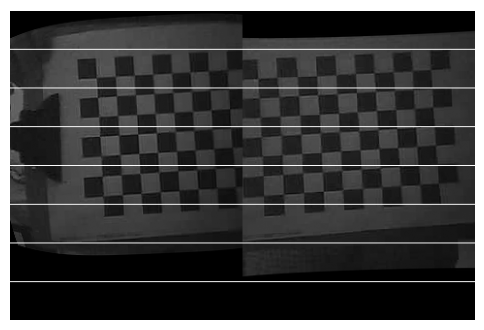

In [3]:
combined = np.hstack((rect_grayL, rect_grayR))

for i in range(0, combined.shape[0], 40):
    cv2.line(combined, (0, i), (combined.shape[1], i), 255, 1)

show(combined, gray=True)

In [4]:
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16*4,  # 64
    blockSize=7,
    P1=8*1*7**2,
    P2=32*1*7**2,
    uniquenessRatio=5,
    speckleWindowSize=50,
    speckleRange=1
)

disparity = stereo.compute(rect_grayL, rect_grayR).astype(np.float32) / 16.0
print("min:", np.min(disparity))
print("max:", np.max(disparity))

min: -1.0
max: 63.0


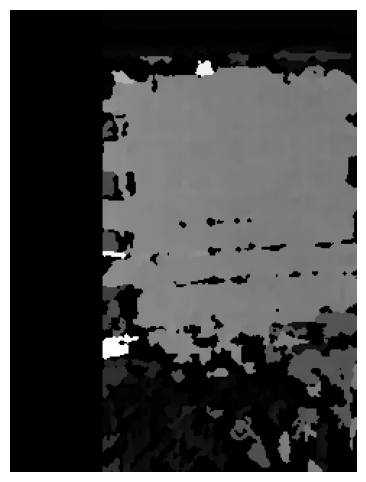

In [5]:
disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp_vis = disp_vis.astype(np.uint8)
show(disp_vis, gray=True)